# Zero-Shot Linking Demo

This notebook loads a released IdentityPFN checkpoint, scores pandas records, and turns the predicted pairwise match probabilities into views that are useful for duplicate review.


In [1]:
from pathlib import Path
import os

if not Path("identitypfn").exists() and Path("../identitypfn").exists():
    os.chdir("..")

import matplotlib.pyplot as plt
import pandas as pd

import identitypfn as idpfn


## Demo Records

The demo data is made up. `demo_group` is only used to choose examples and sort the larger heatmap; it is dropped before scoring.


In [2]:
demo_people = pd.read_csv("notebooks/data/demo_people.csv").set_index("record_id")
demo_people.head()


,demo_group,first_name,last_name,email,phone,city,organization
record_id,,,,,,,
ada_0,lovelace,Ada,Lovelace,ada.lovelace@analytical.example,+44 20 5555 0101,London,Analytical Engine Notes
ada_1,lovelace,A.,Lovelace,ada.lovelace@analytical.example,020 5555 0101,London,Analytical Engine
shannon_0,shannon,Claude,Shannon,claude.shannon@bell.example,+1 973 555 0120,Murray Hill,Bell Labs
shannon_1,shannon,C. E.,Shannon,claude.shannon@bell.example,973-555-0120,Murray Hill,Bell Telephone Labs
tukey_0,tukey,John,Tukey,john.tukey@princeton.example,+1 609 555 0131,Princeton,Princeton


## Small API Example

Start with a small subset so the core calls are easy to see.


In [3]:
records = demo_people.head(6).drop(columns=["demo_group"])
records


,first_name,last_name,email,phone,city,organization
record_id,,,,,,
ada_0,Ada,Lovelace,ada.lovelace@analytical.example,+44 20 5555 0101,London,Analytical Engine Notes
ada_1,A.,Lovelace,ada.lovelace@analytical.example,020 5555 0101,London,Analytical Engine
shannon_0,Claude,Shannon,claude.shannon@bell.example,+1 973 555 0120,Murray Hill,Bell Labs
shannon_1,C. E.,Shannon,claude.shannon@bell.example,973-555-0120,Murray Hill,Bell Telephone Labs
tukey_0,John,Tukey,john.tukey@princeton.example,+1 609 555 0131,Princeton,Princeton
noether_0,Emmy,Noether,emmy.noether@gottingen.example,+49 551 555 0200,Gottingen,University of Gottingen


In [4]:
field_type_details = idpfn.infer_field_types(records)

pd.DataFrame(
    field_type_details,
    columns=["field_type", "reason"],
    index=records.columns,
)


,field_type,reason
first_name,text,fallback
last_name,text,fallback
email,email,column_name
phone,phone,column_name
city,text,fallback
organization,text,fallback


## Load Checkpoint and Score Pairs


In [5]:
device = idpfn.get_default_device()
device


'mps'

In [6]:
checkpoint_path = Path(
    "results/model_checkpoints/20260715_195803_seed1337_20005214_best_step1500.pt"
)
linker = idpfn.load_model(checkpoint_path, device=device)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
scores = linker.predict_proba(records, field_types="infer", verbose=True)
scores.round(3)


      column field_type      reason
  first_name       text    fallback
   last_name       text    fallback
       email      email column_name
       phone      phone column_name
        city       text    fallback
organization       text    fallback


record_id,ada_0,ada_1,shannon_0,shannon_1,tukey_0,noether_0
record_id,,,,,,
ada_0,1.000,0.999,0.000,0.000,0.005,0.304
ada_1,0.999,1.000,0.000,0.000,0.004,0.008
shannon_0,0.000,0.000,1.000,0.998,0.000,0.295
shannon_1,0.000,0.000,0.998,1.000,0.000,0.012
tukey_0,0.005,0.004,0.000,0.000,1.000,0.000
noether_0,0.304,0.008,0.295,0.012,0.000,1.000


## Small Pair Review


In [8]:
idpfn.pair_review_table(
    scores,
    records,
    k=8,
    columns=["first_name", "last_name", "email", "phone", "city", "organization"],
).round({"score": 3})


,left_index,right_index,score,left_first_name,right_first_name,left_last_name,right_last_name,left_email,right_email,left_phone,right_phone,left_city,right_city,left_organization,right_organization
0,ada_0,ada_1,0.999,Ada,A.,Lovelace,Lovelace,ada.lovelace@analytical.example,ada.lovelace@analytical.example,+44 20 5555 0101,020 5555 0101,London,London,Analytical Engine Notes,Analytical Engine
1,shannon_0,shannon_1,0.998,Claude,C. E.,Shannon,Shannon,claude.shannon@bell.example,claude.shannon@bell.example,+1 973 555 0120,973-555-0120,Murray Hill,Murray Hill,Bell Labs,Bell Telephone Labs
2,ada_0,noether_0,0.304,Ada,Emmy,Lovelace,Noether,ada.lovelace@analytical.example,emmy.noether@gottingen.example,+44 20 5555 0101,+49 551 555 0200,London,Gottingen,Analytical Engine Notes,University of Gottingen
3,shannon_0,noether_0,0.295,Claude,Emmy,Shannon,Noether,claude.shannon@bell.example,emmy.noether@gottingen.example,+1 973 555 0120,+49 551 555 0200,Murray Hill,Gottingen,Bell Labs,University of Gottingen
4,shannon_1,noether_0,0.012,C. E.,Emmy,Shannon,Noether,claude.shannon@bell.example,emmy.noether@gottingen.example,973-555-0120,+49 551 555 0200,Murray Hill,Gottingen,Bell Telephone Labs,University of Gottingen
5,ada_1,noether_0,0.008,A.,Emmy,Lovelace,Noether,ada.lovelace@analytical.example,emmy.noether@gottingen.example,020 5555 0101,+49 551 555 0200,London,Gottingen,Analytical Engine,University of Gottingen
6,ada_0,tukey_0,0.005,Ada,John,Lovelace,Tukey,ada.lovelace@analytical.example,john.tukey@princeton.example,+44 20 5555 0101,+1 609 555 0131,London,Princeton,Analytical Engine Notes,Princeton
7,ada_1,tukey_0,0.004,A.,John,Lovelace,Tukey,ada.lovelace@analytical.example,john.tukey@princeton.example,020 5555 0101,+1 609 555 0131,London,Princeton,Analytical Engine,Princeton


## Larger Visual Example

For a more realistic visual pass, score the full demo table after sorting records by the hidden demo group. The model still only receives the visible record columns.


In [9]:
visual_people = demo_people.sort_values(["demo_group", "record_id"])
visual_records = visual_people.drop(columns=["demo_group"])
visual_scores = linker.predict_proba(visual_records, field_types="infer", verbose=False)
visual_records.head()


,first_name,last_name,email,phone,city,organization
record_id,,,,,,
dirichlet_0,Peter,Dirichlet,peter.dirichlet@berlin.example,+49 30 555 0170,Berlin,University of Berlin
dirichlet_1,P. G. L.,Dirichlet,pgl.dirichlet@berlin.example,030 555 0170,Berlin,Universitat Berlin
dirichlet_2,Lejeune,Dirichlet,dirichlet@gottingen.example,+49 551 555 0170,Gottingen,University of Gottingen
euler_0,Leonhard,Euler,leonhard.euler@basel.example,+41 61 555 0150,Basel,St Petersburg Academy
euler_1,L.,Euler,l.euler@academy.example,061 555 0150,Basel,Imperial Academy


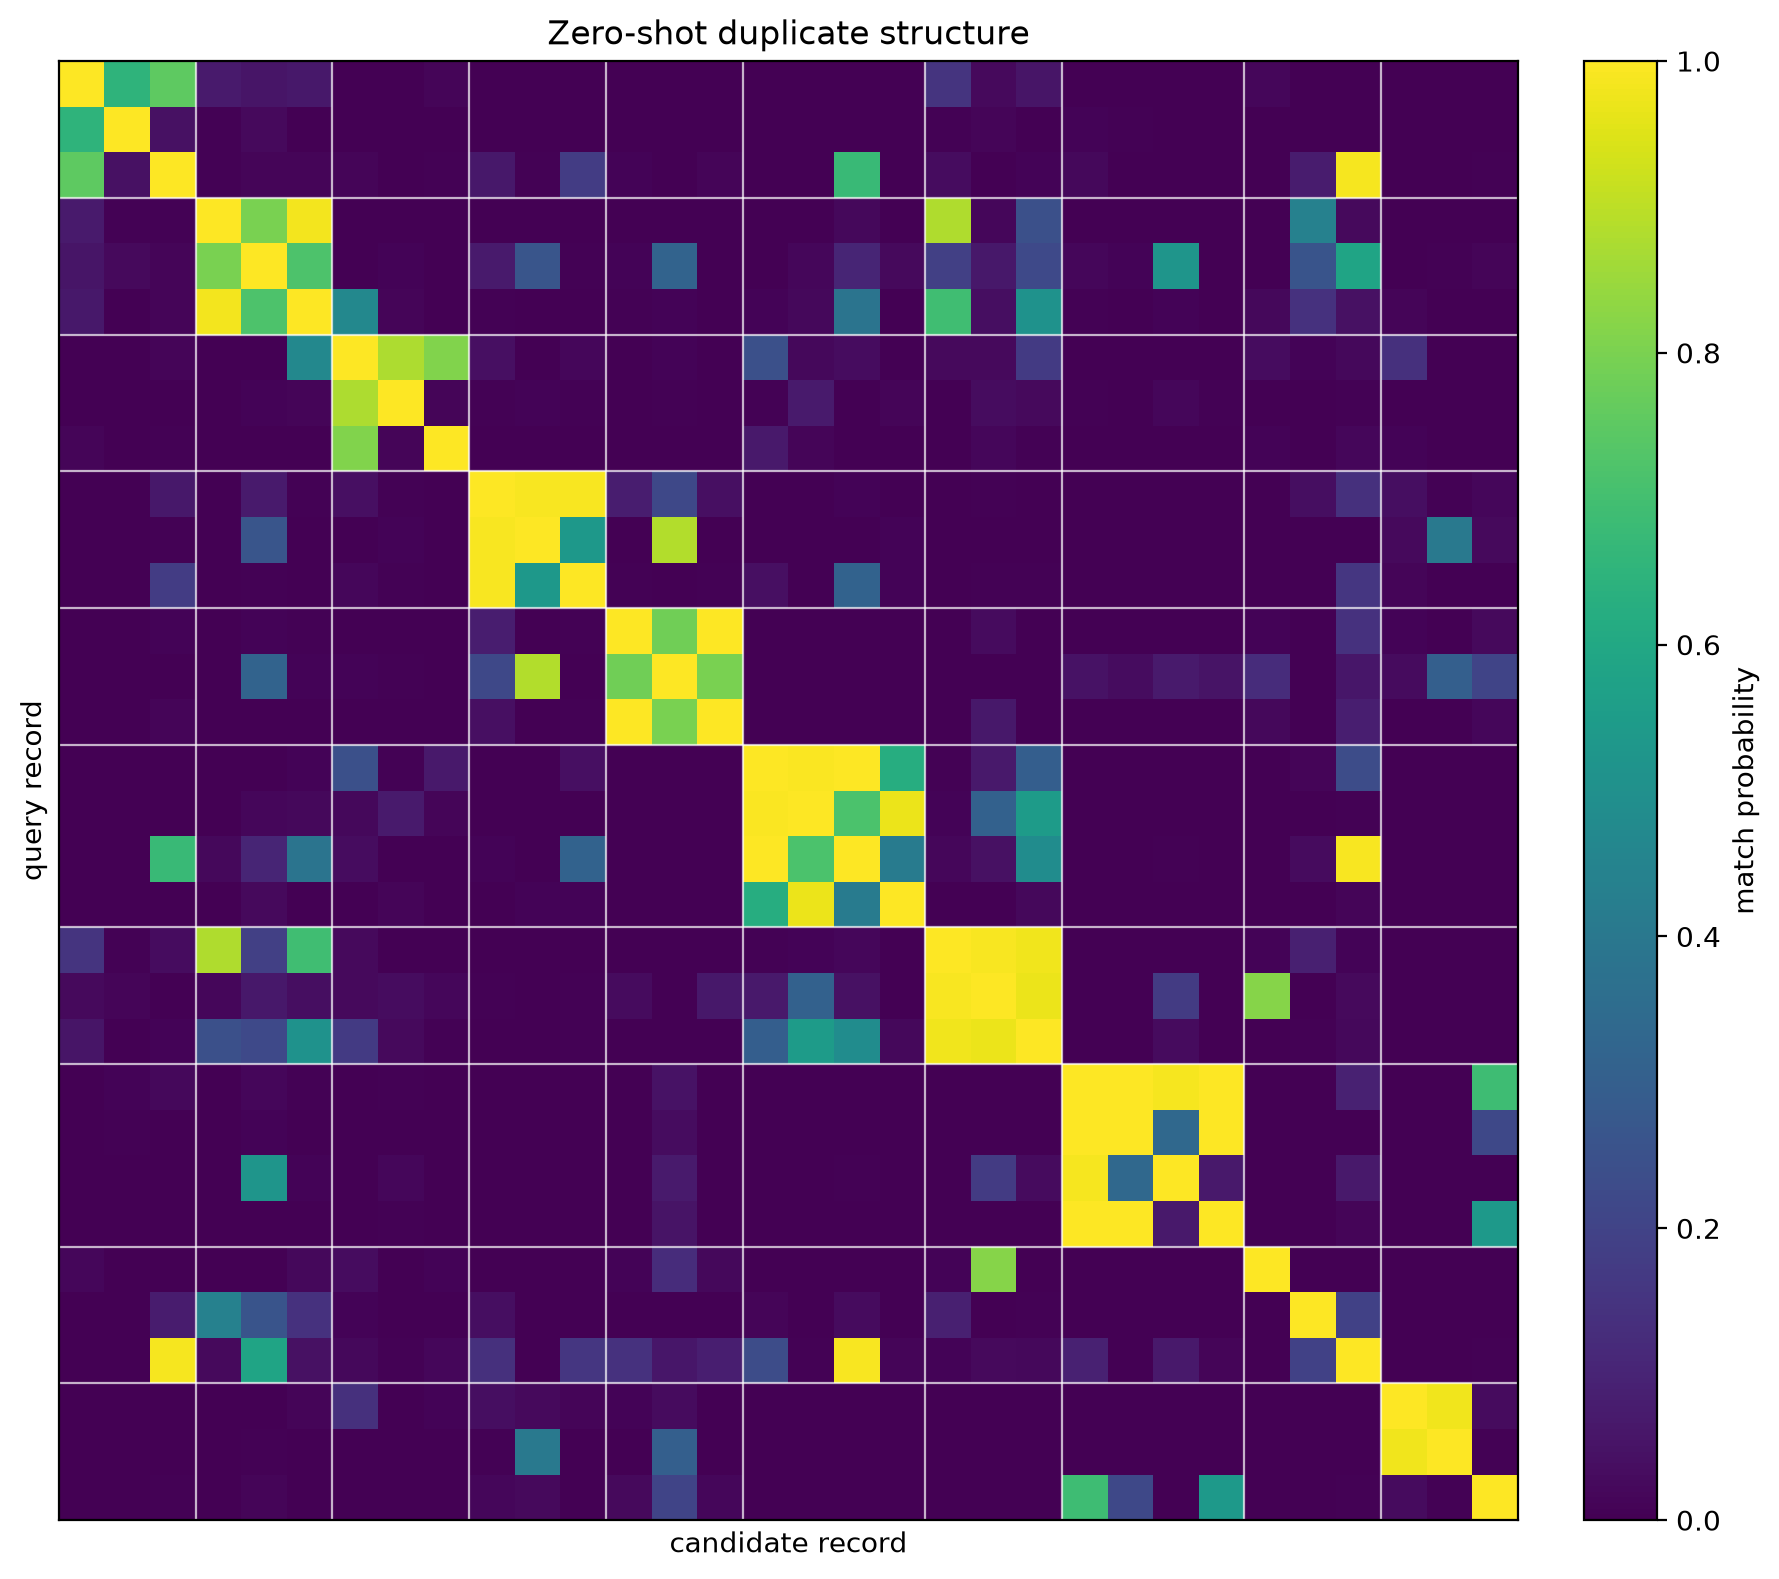

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(visual_scores, vmin=0, vmax=1, cmap="viridis")
ax.set_title("Zero-shot duplicate structure")
ax.set_xlabel("candidate record")
ax.set_ylabel("query record")
ax.set_xticks([])
ax.set_yticks([])

last_group = None
for position, group in enumerate(visual_people["demo_group"]):
    if last_group is not None and group != last_group:
        ax.axhline(position - 0.5, color="white", linewidth=0.8, alpha=0.7)
        ax.axvline(position - 0.5, color="white", linewidth=0.8, alpha=0.7)
    last_group = group

fig.colorbar(image, ax=ax, label="match probability", fraction=0.046, pad=0.04)
fig.tight_layout()


In [11]:
idpfn.top_pairs(visual_scores, k=12)


,left_index,right_index,score
0,johnson_0,johnson_2,0.999921
1,shannon_1,shannon_3,0.999591
2,ada_0,ada_2,0.998857
3,shannon_0,shannon_3,0.998301
4,shannon_0,shannon_1,0.996911
5,ada_0,ada_1,0.995861
6,hopper_0,hopper_1,0.991452
7,hopper_0,hopper_2,0.991332
8,ada_2,noether_0,0.990619
9,poisson_0,poisson_1,0.990033


In [12]:
idpfn.nearest_neighbors(visual_scores, k=3).head(12)


,query_index,neighbor_index,rank,score
0,dirichlet_0,dirichlet_2,1,0.753757
1,dirichlet_0,dirichlet_1,2,0.650141
2,dirichlet_0,poisson_0,3,0.151853
3,dirichlet_1,dirichlet_0,1,0.650141
4,dirichlet_1,dirichlet_2,2,0.044363
5,dirichlet_1,euler_1,3,0.025967
6,dirichlet_2,noether_0,1,0.986078
7,dirichlet_2,dirichlet_0,2,0.753757
8,dirichlet_2,ada_2,3,0.678424
9,euler_0,euler_2,1,0.982121


In [13]:
idpfn.pair_review_table(
    visual_scores,
    visual_records,
    k=12,
    columns=["first_name", "last_name", "email", "phone", "city", "organization"],
).round({"score": 3})


,left_index,right_index,score,left_first_name,right_first_name,left_last_name,right_last_name,left_email,right_email,left_phone,right_phone,left_city,right_city,left_organization,right_organization
0,johnson_0,johnson_2,1.000,Katherine,Katherine G.,Johnson,Johnson,katherine.johnson@nasa.example,katherine.j@nasa.example,+1 757 555 0190,+1 757 555 0191,Hampton,Hampton,NASA,NASA Langley
1,shannon_1,shannon_3,1.000,C. E.,Claude,Shannon,Shanon,claude.shannon@bell.example,claude.shannon@bell.example,973-555-0120,9735550120,Murray Hill,Murray Hill,Bell Telephone Labs,Bell Labs
2,ada_0,ada_2,0.999,Ada,Augusta Ada,Lovelace,King,ada.lovelace@analytical.example,ada.king@math.example,+44 20 5555 0101,+44 20 5555 0101,London,London,Analytical Engine Notes,Analytical Engine Notes
3,shannon_0,shannon_3,0.998,Claude,Claude,Shannon,Shanon,claude.shannon@bell.example,claude.shannon@bell.example,+1 973 555 0120,9735550120,Murray Hill,Murray Hill,Bell Labs,Bell Labs
4,shannon_0,shannon_1,0.997,Claude,C. E.,Shannon,Shannon,claude.shannon@bell.example,claude.shannon@bell.example,+1 973 555 0120,973-555-0120,Murray Hill,Murray Hill,Bell Labs,Bell Telephone Labs
5,ada_0,ada_1,0.996,Ada,A.,Lovelace,Lovelace,ada.lovelace@analytical.example,ada.lovelace@analytical.example,+44 20 5555 0101,020 5555 0101,London,London,Analytical Engine Notes,Analytical Engine
6,hopper_0,hopper_1,0.991,Grace,Grace M.,Hopper,Hopper,grace.hopper@navy.example,g.hopper@navy.example,+1 703 555 0180,703-555-0180,Arlington,Arlington,US Navy,Navy
7,hopper_0,hopper_2,0.991,Grace,Amazing Grace,Hopper,Hopper,grace.hopper@navy.example,grace.hopper@cobol.example,+1 703 555 0180,+1 212 555 0180,Arlington,New York,US Navy,CODASYL
8,ada_2,noether_0,0.991,Augusta Ada,Emmy,King,Noether,ada.king@math.example,emmy.noether@gottingen.example,+44 20 5555 0101,+49 551 555 0200,London,Gottingen,Analytical Engine Notes,University of Gottingen
9,poisson_0,poisson_1,0.990,Simeon,S. D.,Poisson,Poisson,simeon.poisson@polytechnique.example,sd.poisson@polytechnique.example,+33 1 55 50 1600,01 55 50 16 00,Paris,Paris,Ecole Polytechnique,Ecole Polytechnique


## Two-Table Linkage Helper

**Two-table linkage is currently a convenience wrapper, not a native bipartite IdentityPFN architecture.** It stacks aligned columns from two tables, scores the combined record set, and returns only cross-table pairs.


In [14]:
left_people = pd.DataFrame(
    [
        {
            "full_name": "Ada Lovelace",
            "email": "ada.lovelace@analytical.example",
            "phone": "+44 20 5555 0101",
            "city": "London",
            "source": "crm",
        },
        {
            "full_name": "Claude Shannon",
            "email": "claude.shannon@bell.example",
            "phone": "+1 973 555 0120",
            "city": "Murray Hill",
            "source": "crm",
        },
        {
            "full_name": "John Tukey",
            "email": "john.tukey@princeton.example",
            "phone": "+1 609 555 0131",
            "city": "Princeton",
            "source": "crm",
        },
    ],
    index=["left_0", "left_1", "left_2"],
)

right_people = pd.DataFrame(
    [
        {
            "display_name": "A. Lovelace",
            "email_address": "ada.lovelace@analytical.example",
            "telephone": "020 5555 0101",
            "location": "London",
            "notes": "unmapped column retained outside model input",
        },
        {
            "display_name": "C. E. Shannon",
            "email_address": "claude.shannon@bell.example",
            "telephone": "973-555-0120",
            "location": "Murray Hill",
            "notes": "unmapped column retained outside model input",
        },
        {
            "display_name": "R. A. Fisher",
            "email_address": "ra.fisher@rothamsted.example",
            "telephone": "01582 555014",
            "location": "Harpenden",
            "notes": "unmapped column retained outside model input",
        },
    ],
    index=["right_0", "right_1", "right_2"],
)

idpfn.score_linkage(
    linker,
    left_people,
    right_people,
    columns={
        "name": ("full_name", "display_name"),
        "email": ("email", "email_address"),
        "phone": ("phone", "telephone"),
        "city": ("city", "location"),
    },
    field_types="infer",
    k=5,
)


,left_index,right_index,score,left_name,right_name,left_email,right_email,left_phone,right_phone,left_city,right_city
0,left_0,right_0,0.998100,Ada Lovelace,A. Lovelace,ada.lovelace@analytical.example,ada.lovelace@analytical.example,+44 20 5555 0101,020 5555 0101,London,London
1,left_1,right_1,0.997475,Claude Shannon,C. E. Shannon,claude.shannon@bell.example,claude.shannon@bell.example,+1 973 555 0120,973-555-0120,Murray Hill,Murray Hill
2,left_2,right_2,0.051832,John Tukey,R. A. Fisher,john.tukey@princeton.example,ra.fisher@rothamsted.example,+1 609 555 0131,01582 555014,Princeton,Harpenden
3,left_1,right_2,0.036518,Claude Shannon,R. A. Fisher,claude.shannon@bell.example,ra.fisher@rothamsted.example,+1 973 555 0120,01582 555014,Murray Hill,Harpenden
4,left_0,right_2,0.003803,Ada Lovelace,R. A. Fisher,ada.lovelace@analytical.example,ra.fisher@rothamsted.example,+44 20 5555 0101,01582 555014,London,Harpenden
